In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

                                 AAPL        AMZN        TSLA        WMT  \
Date                                                                       
2019-01-02 00:00:00-05:00   37.503738   76.956497   20.674667  27.967051   
2019-01-03 00:00:00-05:00   33.768082   75.014000   20.024000  27.823231   
2019-01-04 00:00:00-05:00   35.209610   78.769501   21.179333  27.997019   
2019-01-07 00:00:00-05:00   35.131237   81.475502   22.330667  28.326599   
2019-01-08 00:00:00-05:00   35.800953   82.829002   22.356667  28.524349   
...                               ...         ...         ...        ...   
2024-12-24 00:00:00-05:00  256.797180  229.050003  462.279999  91.613258   
2024-12-26 00:00:00-05:00  257.612732  227.050003  454.130005  91.722000   
2024-12-27 00:00:00-05:00  254.201370  223.750000  431.660004  90.605011   
2024-12-30 00:00:00-05:00  250.829788  221.300003  417.410004  89.527534   
2024-12-31 00:00:00-05:00  249.059464  219.389999  403.839996  89.310074   

           

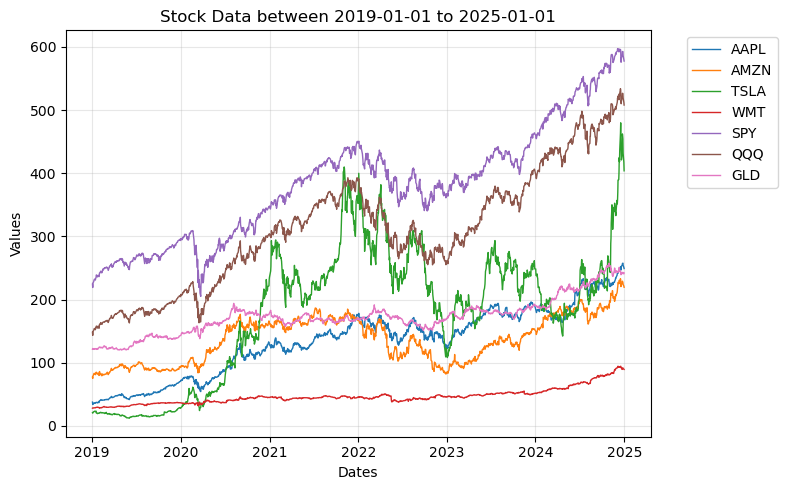

The log returns 
                                AAPL      AMZN      TSLA       WMT       SPY  \
Date                                                                          
2019-01-03 00:00:00-05:00 -0.104925 -0.025566 -0.031978 -0.005156 -0.024152   
2019-01-04 00:00:00-05:00  0.041803  0.048851  0.056094  0.006227  0.032947   
2019-01-07 00:00:00-05:00 -0.002228  0.033777  0.052935  0.011703  0.007853   
2019-01-08 00:00:00-05:00  0.018884  0.016476  0.001164  0.006957  0.009352   
2019-01-09 00:00:00-05:00  0.016839  0.001713  0.009438 -0.003261  0.004663   
...                             ...       ...       ...       ...       ...   
2024-12-24 00:00:00-05:00  0.011413  0.017573  0.070991  0.025462  0.011054   
2024-12-26 00:00:00-05:00  0.003171 -0.008770 -0.017787  0.001186  0.000067   
2024-12-27 00:00:00-05:00 -0.013331 -0.014641 -0.050745 -0.012253 -0.010583   
2024-12-30 00:00:00-05:00 -0.013352 -0.011010 -0.033569 -0.011963 -0.011477   
2024-12-31 00:00:00-05:00 -0.00708

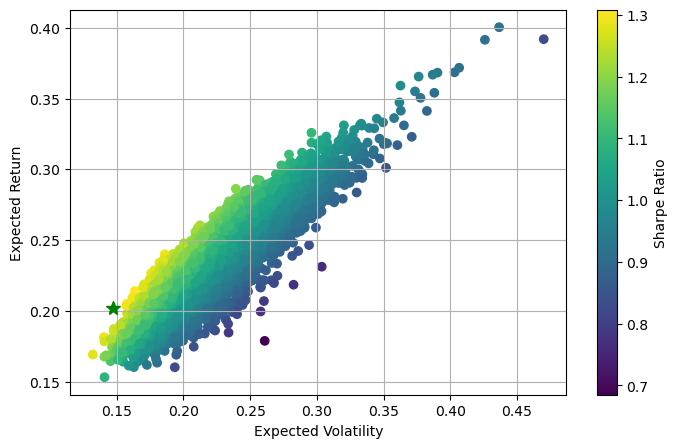

In [4]:
# On average there are 252 days of trading per year
Num_trading_days = 252

# We will generate random weights (different portfolios)
Num_of_portfolios = 10000

assets = ["AAPL", "AMZN", "TSLA", "WMT", "SPY", "QQQ", "GLD"]

start_date = "2019-01-01"
end_date = "2025-01-01"

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 1)  Sourcing the data from Yahoo Finance for all the above mentioned assests
def source_data():
    # Store the data into a dictionary where keys are the names of assests and values are the values of assests
    asset_data = {}
    for asset in assets:
        ticker = yf.Ticker(asset)
        asset_data[asset] = ticker.history(start = start_date, end = end_date)["Close"]
    print(pd.DataFrame(asset_data))
    return pd.DataFrame(asset_data)


# Visualization of the source data of assets

def source_data_show(df):
    plt.figure(figsize=(8, 5))
    for column in df.columns:
        plt.plot(df.index, df[column], label=column, linewidth=1)
    plt.xlabel('Dates')
    plt.ylabel('Values')
    plt.title(f'Stock Data between {start_date} to {end_date}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 2) Return Calculations

def log_return(df):
    log_return = np.log(df / df.shift(1))
    log_return = log_return.dropna()
    print("The log returns \n", log_return)
    print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
    return log_return

def expected_return(returns):
    expected_returns = returns.mean() * Num_trading_days
    print("The expected returns (mean) \n", expected_returns)
    print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
    return expected_returns

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 3) Covariance Matrix (Risk Relationships)

def covariance_matrix(returns):
    covariance = returns.cov() * Num_trading_days
    print("The covariance matrix \n", covariance)
    print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
    return covariance

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 4) Generating the weights for the different portfolios
def different_portfolios(returns):
    portfolio_weights = []
    portfolio_mean = []
    portfolio_risks = []
    
    for _ in range(Num_of_portfolios):
        w = np.random.random(len(assets))
        w /= np.sum(w)
        portfolio_weights.append(w)
        portfolio_mean.append(np.sum(returns.mean() * w)
                              * Num_trading_days)
        portfolio_risks.append(np.sqrt(
            np.dot(w.T, np.dot(returns.cov() * Num_trading_days, w))))
    print("Portfolio Weights \n",np.array(portfolio_weights))
    print("\nPortfolio Returns \n",np.array(portfolio_mean))
    print("\nPortfolio Risks \n",np.array(portfolio_risks))
    print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
    return np.array(portfolio_weights), np.array(portfolio_mean), np.array(portfolio_risks)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 5) Portfolio Return

def portfolio_return(weights, returns):
    portfolio_return = np.sum(returns.mean() * weights) * Num_trading_days

    return np.array(portfolio_return)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 6) Portfolio Risk (Volatility)
    
def portfolio_risk(weights, returns):
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * Num_trading_days, weights)))
    return np.array(portfolio_volatility)


#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 7) Sharpe Ratio (Risk-Adjusted Return)

def sharpe_calculation(weights, returns):
    port_return  = np.sum(returns.mean() * weights) * Num_trading_days
    port_risk = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * Num_trading_days, weights)))    
    sharpe_ratio = port_return / port_risk
    return -np.array(sharpe_ratio)



#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# 8) Optimization Problem

# We will use scipy to optimise the portfolio. The scipy library can find the 
# minimum of a function. In this problem we are looking to maximise the Sharpe
# Ratio, therefore we will use minimum of -f(x) as it is the maximum of f(x).

# According to Modern Portfolio Theory. The sum of weigjts must be equal to 1.
# To employe the optimisation technique we need constraints.

# Method 'SLSQP' was selected because because the Markowitz optimization 
#problem involves a nonlinear objective (Sharpe ratio) with both equality 
# and bound constraints, making it well-suited for constrained gradient-based
# optimization.

def optimise_portfolio(weights, returns):
    num_assets = len(assets)
    x0 = np.ones(num_assets) / num_assets
    weight_bounds = tuple((0, 1) for _ in range(len(assets)))
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    return minimize(fun = sharpe_calculation, x0 = x0,
                                 args = returns, method = 'SLSQP', 
                                 bounds = weight_bounds, 
                                 constraints = constraints)
                                 
def The_optimal_portfolio(optimum, returns): 
    print("The optimal portfolio: ", optimum['x'])
    print("The optimal portfolio return: ", portfolio_return(np.round(optimum['x'],3), returns))
    print("The optimal portfolio risk: ", portfolio_risk(np.round(optimum['x'],3), returns))
    print("The optimal sharpe ratio: ", abs(sharpe_calculation(np.round(optimum['x'],3), returns)))


def visualize_optimal_port(optimum, returns, port_ret, port_ri):
    plt.figure(figsize = (8, 5))
    plt.scatter(port_ri, port_ret, c = port_ret / port_ri, marker = 'o')
    plt.plot(portfolio_risk(optimum['x'], returns), portfolio_return(optimum['x'], returns), 'g*', markersize=10)
    plt.colorbar(label = 'Sharpe Ratio')
    plt.xlabel("Expected Volatility")
    plt.ylabel("Expected Return")
    plt.grid(True)
    plt.show()
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
if __name__ == "__main__":
    data = source_data()
    source_data_show(data)
    return_data = log_return(data)
    expected_return(return_data)
    covariance_matrix(return_data)
    g_weight, mean, risk = different_portfolios(return_data)
    sharpe_calculation(g_weight[0], return_data)
    optimum_portfolio = optimise_portfolio(g_weight, return_data)
    The_optimal_portfolio(optimum_portfolio, return_data)
    visualize_optimal_port(optimum_portfolio, return_data, mean, risk)